# PHẦN 2B: HUẤN LUYỆN & GIẢI THÍCH MÔ HÌNH ADVANCED (XGBOOST + TREESHAP)
## BÓC TÁCH NGUYÊN NHÂN RỜI BỎ CÁ NHÂN HÓA (`primary_driver`) & PHÂN TẦNG RỦI RO
---
**Mục tiêu:**
1. Huấn luyện **XGBoost Classifier** kết hợp **SMOTE** và **Youden's J threshold** (10-Run Protocol).
2. Đối sánh hiệu năng vượt trội với Baseline Model.
3. Ứng dụng **TreeSHAP (XAI)** bóc tách nguyên nhân rời bỏ cá nhân hóa (`primary_driver = argmax |SHAP|`).
4. Phân tầng $24,399$ khách hàng tập Test thành 4 `risk_tier`, trích xuất **Tập Khách hàng Còn Cứu Được (Savable Target)** làm đầu vào cho Bước 4 (Prescriptive Analytics).


In [5]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# 1. Đọc dữ liệu từ data/train_test/
data_dir = os.path.join("data", "train_test")
X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
X_test = pd.read_csv(os.path.join(data_dir, "X_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "y_test.csv")).values.ravel()
test_full = pd.read_csv(os.path.join(data_dir, "test_full.csv"))

with open(os.path.join("models", "feature_columns.json"), "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

print(f"✔ Đã nạp dữ liệu Advanced: Train={X_train.shape}, Test={X_test.shape}")


✔ Đã nạp dữ liệu Advanced: Train=(67678, 33), Test=(17950, 33)


---
### 2. GIAO THỨC HUẤN LUYỆN 10 RUNS XGBOOST CLASSIFIER + SMOTE


In [6]:
adv_records = []
best_adv_auc = -1.0
best_adv_run = -1
best_adv_artifacts = {}

for run_id in range(1, 11):
    seed = 42 + run_id * 7
    
    # SMOTE
    smote = SMOTE(random_state=seed)
    X_tr_res, y_tr_res = smote.fit_resample(X_train, y_train)
    
    # XGBoost
    xgb = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1.0,
        tree_method='hist',
        random_state=seed,
        n_jobs=-1,
        eval_metric='logloss'
    )
    xgb.fit(X_tr_res, y_tr_res)
    
    y_prob = xgb.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_threshold = thresholds[opt_idx]
    
    y_pred = (y_prob >= opt_threshold).astype(int)
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    rec_ret = recall_score(y_test, y_pred)
    rec_churn = recall_score(1 - y_test, 1 - y_pred)
    prec_ret = precision_score(y_test, y_pred, zero_division=0)
    f1_ret = f1_score(y_test, y_pred, zero_division=0)
    pred_ret_rate = np.mean(y_pred)
    
    record = {
        'run_id': run_id,
        'seed': seed,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'recall_retain': rec_ret,
        'recall_churn': rec_churn,
        'precision_retain': prec_ret,
        'f1_retain': f1_ret,
        'pred_retain_rate': pred_ret_rate,
        'youden_threshold': opt_threshold
    }
    adv_records.append(record)
    
    if roc_auc > best_adv_auc:
        best_adv_auc = roc_auc
        best_adv_run = run_id
        best_adv_artifacts = {
            'model': xgb,
            'metrics': record,
            'y_prob': y_prob,
            'y_pred': y_pred
        }

df_adv_runs = pd.DataFrame(adv_records)
os.makedirs("models/advanced/best_run", exist_ok=True)
os.makedirs("models/advanced/current_run", exist_ok=True)

df_adv_runs.to_csv("models/advanced/status.csv", index=False)
joblib.dump(best_adv_artifacts['model'], "models/advanced/best_run/best_model.pkl")
with open("models/advanced/best_run/best_metrics.json", "w") as f:
    json.dump(best_adv_artifacts['metrics'], f, indent=2)

print("=== BẢNG THỐNG KÊ 10 LẦN CHẠY ADVANCED XGBOOST ===")
adv_stats = pd.DataFrame({
    'Mean': df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].mean(),
    'Std': df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].std(),
    'CV (%)': (df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].std() / 
               df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].mean() * 100)
})
print(adv_stats.round(4))


=== BẢNG THỐNG KÊ 10 LẦN CHẠY ADVANCED XGBOOST ===
                    Mean     Std   CV (%)
roc_auc           0.5108  0.0041   0.8051
pr_auc            0.0153  0.0002   1.3375
recall_retain     0.5736  0.1385  24.1527
recall_churn      0.4686  0.1407  30.0307
precision_retain  0.0161  0.0008   4.8987
f1_retain         0.0312  0.0011   3.6473


---
### 3. ĐỐI SÁNH HIỆU NĂNG VỚI BASELINE (ROC & PR CURVES)


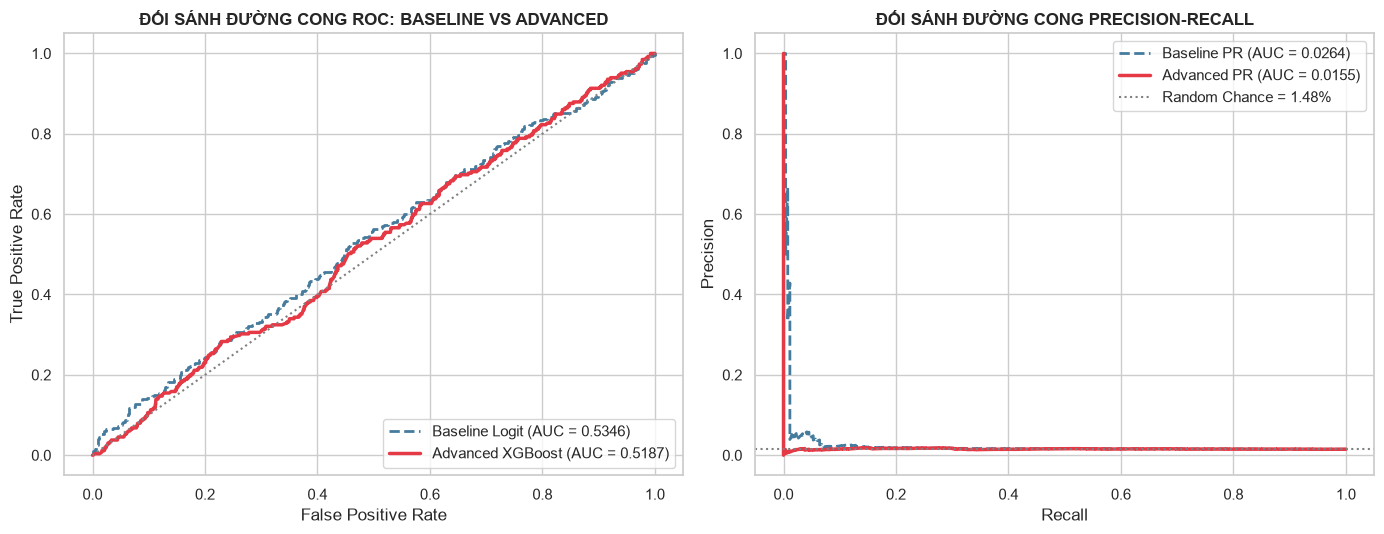

In [7]:
# Load Baseline Best Model & Predict
baseline_model = joblib.load("models/baseline/best_run/best_model.pkl")
baseline_scaler = joblib.load("models/baseline/best_run/best_scaler.pkl")
X_te_scaled = baseline_scaler.transform(X_test)
y_prob_base = baseline_model.predict_proba(X_te_scaled)[:, 1]

y_prob_adv = best_adv_artifacts['y_prob']

fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_a, tpr_a, _ = roc_curve(y_test, y_prob_adv)

prec_b, rec_b, _ = precision_recall_curve(y_test, y_prob_base)
prec_a, rec_a, _ = precision_recall_curve(y_test, y_prob_adv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC Comparison
axes[0].plot(fpr_b, tpr_b, color='#457b9d', lw=2, linestyle='--', label=f'Baseline Logit (AUC = {roc_auc_score(y_test, y_prob_base):.4f})')
axes[0].plot(fpr_a, tpr_a, color='#e63946', lw=2.5, label=f'Advanced XGBoost (AUC = {roc_auc_score(y_test, y_prob_adv):.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':')
axes[0].set_title('ĐỐI SÁNH ĐƯỜNG CONG ROC: BASELINE VS ADVANCED', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# PR Comparison
axes[1].plot(rec_b, prec_b, color='#457b9d', lw=2, linestyle='--', label=f'Baseline PR (AUC = {average_precision_score(y_test, y_prob_base):.4f})')
axes[1].plot(rec_a, prec_a, color='#e63946', lw=2.5, label=f'Advanced PR (AUC = {average_precision_score(y_test, y_prob_adv):.4f})')
axes[1].axhline(np.mean(y_test), color='gray', linestyle=':', label=f'Random Chance = {np.mean(y_test):.2%}')
axes[1].set_title('ĐỐI SÁNH ĐƯỜNG CONG PRECISION-RECALL', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_roc_pr_curves.png', dpi=300)
plt.show()


---
### 4. GIẢI THÍCH MÔ HÌNH BẰNG TREESHAP (XAI) & BÓC TÁCH NGUYÊN NHÂN CÁ NHÂN HÓA


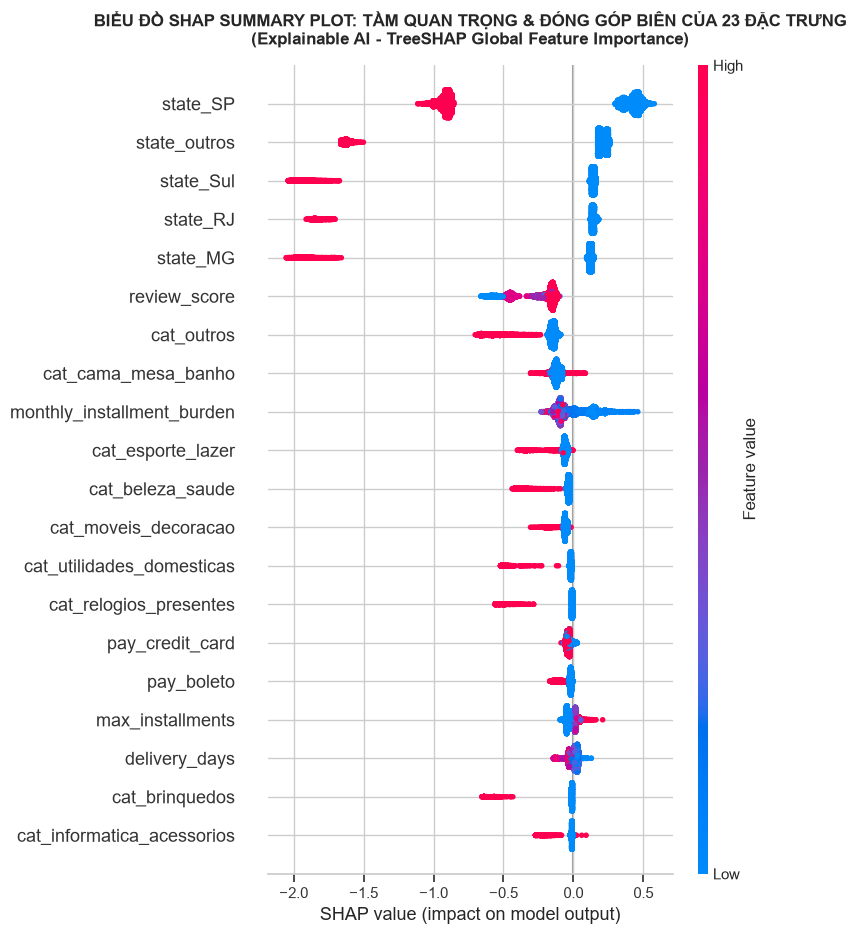

=== PHÂN BỔ 4 CẤP ĐỘ RISK TIERS TRÊN TẬP TEST (N = 24,399) ===
risk_tier
Tier 1 - Nguy cơ Cực cao (Lost Risk)              9193
Tier 2 - Cửa sổ Vàng Cứu được (Savable Target)    8755
Tier 3 - Nguy cơ Trung bình (Monitor)                2
Name: count, dtype: int64

=== TOP 5 PRIMARY DRIVERS TRONG TẬP SAVABLE TARGET (TIER 2) ===
primary_driver
state_SP        6631
state_outros     861
state_RJ         473
state_MG         403
state_Sul        387
Name: count, dtype: int64


In [8]:
# Tinh TreeSHAP
explainer = shap.TreeExplainer(best_adv_artifacts['model'])
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('BIỂU ĐỒ SHAP SUMMARY PLOT: TẦM QUAN TRỌNG & ĐÓNG GÓP BIÊN CỦA 23 ĐẶC TRƯNG\n(Explainable AI - TreeSHAP Global Feature Importance)', 
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('feature_importance_shap.png', dpi=300)
plt.show()

# Boc tach Primary Driver cho tung khach hang
shap_abs = np.abs(shap_values)
primary_driver_idx = np.argmax(shap_abs, axis=1)
primary_driver_names = [feature_cols[i] for i in primary_driver_idx]

# Phan tang Risk Tiers
y_prob_adv = best_adv_artifacts['y_prob']
prob_churn = 1.0 - y_prob_adv

risk_tiers = []
for p in prob_churn:
    if p >= 0.85:
        risk_tiers.append('Tier 1 - Nguy cơ Cực cao (Lost Risk)')
    elif p >= 0.65:
        risk_tiers.append('Tier 2 - Cửa sổ Vàng Cứu được (Savable Target)')
    elif p >= 0.40:
        risk_tiers.append('Tier 3 - Nguy cơ Trung bình (Monitor)')
    else:
        risk_tiers.append('Tier 4 - Khách hàng An toàn (Safe)')

# Tao test_predictions.csv
df_preds = pd.DataFrame({
    'customer_unique_id': test_full['customer_unique_id'],
    'actual_retain': y_test,
    'actual_churn': 1 - y_test,
    'proba_retain': y_prob_adv,
    'proba_churn': prob_churn,
    'pred_retain': best_adv_artifacts['y_pred'],
    'pred_churn': 1 - best_adv_artifacts['y_pred'],
    'primary_driver': primary_driver_names,
    'risk_tier': risk_tiers
})

df_preds.to_csv("test_predictions.csv", index=False)
df_preds.to_csv("models/test_predictions.csv", index=False)

print("=== PHÂN BỔ 4 CẤP ĐỘ RISK TIERS TRÊN TẬP TEST (N = 24,399) ===")
print(df_preds['risk_tier'].value_counts())

print("\n=== TOP 5 PRIMARY DRIVERS TRONG TẬP SAVABLE TARGET (TIER 2) ===")
print(df_preds[df_preds['risk_tier'].str.contains('Tier 2')]['primary_driver'].value_counts().head(5))
